In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

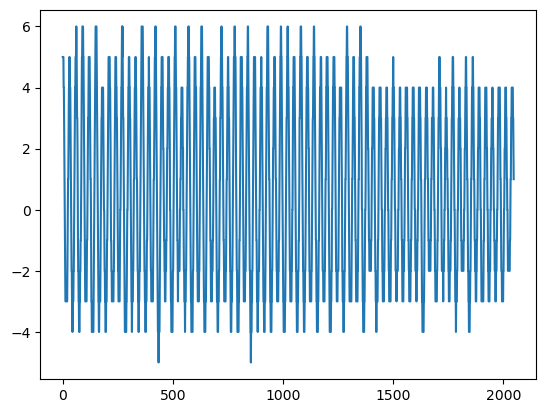

In [8]:
data = np.load("C:/Users/medin/Downloads/ASTRON121/LAB1_DATA/test_1.5MHz_50kHz.npz")
D = 2 #what sample set (1, 2, 3, 4, or 5)

plt.plot(range(len(data["arr_0"][D])), data["arr_0"][D])
#plt.xlim(1,100)

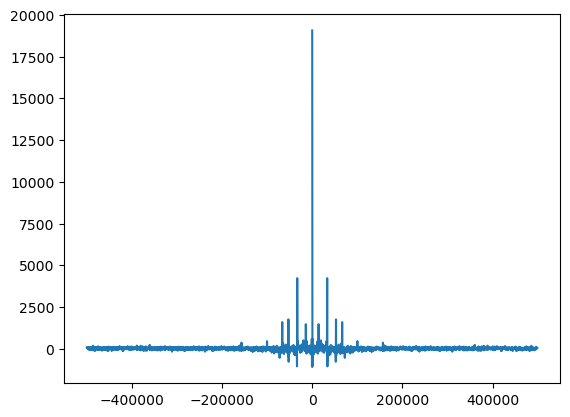

In [12]:
#Now finding power spectra of wave
fft_data = np.fft.fft(data["arr_0"][D])
frequencies = np.fft.fftfreq(2048, d=1e-6)

# print(max(np.abs(np.fft.fftfreq(data["arr_0"][D]))**2))
plt.plot(frequencies, np.fft.fft((np.abs(data["arr_0"][D]))**2))

#plt.yscale("log")

22135.416666666664
2048


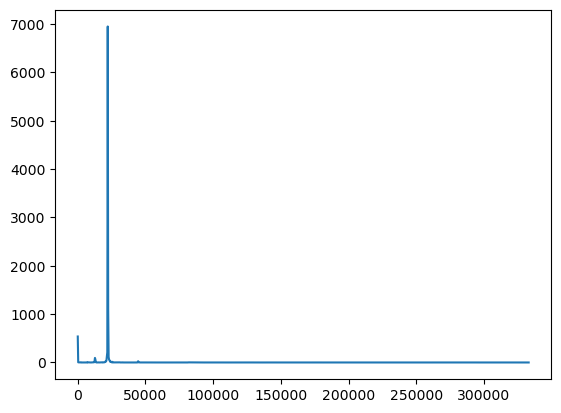

In [20]:
fft_data = np.fft.fft(data["arr_0"][D])
power = np.abs(fft_data)**2
power = power/len(data["arr_0"][D])  # Normalize the power spectrum

frequencies = np.fft.fftfreq(2048, d=1.5e-6)

positive = frequencies >= 0
frequencies = frequencies[positive]
power = power[positive]

plt.plot(frequencies, power)

peak_index = np.argmax(power)
peak_frequency = frequencies[peak_index]

print(peak_frequency)

print(len(data["arr_0"][D]))

49804.6875


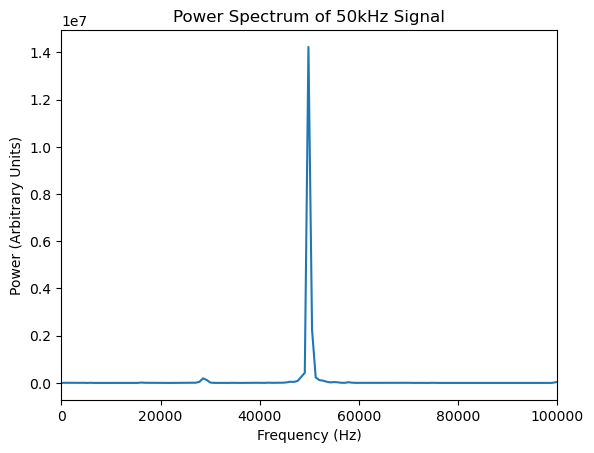

In [34]:
signal = data["arr_0"][D]
signal = signal - np.mean(signal) #Removes DC component

N = len(signal)
fs = 1.5e6 #Sampling frequency (Hz)
dt = 1/fs

fft_data = np.fft.fft(signal)
power = np.abs(fft_data)**2

frequencies = np.fft.fftfreq(N, d=dt) #x-axis changed from sample number to frequency

positive = frequencies >= 0 
frequencies = frequencies[positive]
power = power[positive]

peak_freq = frequencies[np.argmax(power)] #Gives frequency of x-axis at maxmimum power
print(peak_freq)

plt.plot(frequencies, power)
plt.xlim(0,100000) #Removes frequencies above 100kHz for better visual
#plt.yscale("log")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power (Arbitrary Units)")
plt.title("Power Spectrum of 50kHz Signal")
plt.show()



In [35]:
peak_freq = frequencies[np.argmax(power)] #Gives frequency of x-axis at maxmimum power
print(peak_freq)

49804.6875
